# Time Series Forecasting with Classic ML

This notebook shows how to turn a time series into a supervised learning problem using a public dataset.

Dataset: monthly international airline passengers, 1949-1960. The CSV is publicly available at `https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv`. A small fallback copy is embedded so the notebook also works without internet access.

We will cover:

- how time series data differs from ordinary tabular data;
- why chronological train/test splits matter;
- how to create lag and rolling-window features;
- how to compare baseline forecasts with classic ML models;
- how to forecast future values recursively.

In [1]:
from io import StringIO
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (10, 5),
})

pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42

## 1. Load a Public Monthly Time Series

The dataset has one row per month and one target column: the number of international airline passengers, in thousands. It is a useful teaching dataset because it has a clear upward trend and a repeated yearly pattern.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

FALLBACK_CSV = """Month,Passengers
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121
1949-06,135
1949-07,148
1949-08,148
1949-09,136
1949-10,119
1949-11,104
1949-12,118
1950-01,115
1950-02,126
1950-03,141
1950-04,135
1950-05,125
1950-06,149
1950-07,170
1950-08,170
1950-09,158
1950-10,133
1950-11,114
1950-12,140
1951-01,145
1951-02,150
1951-03,178
1951-04,163
1951-05,172
1951-06,178
1951-07,199
1951-08,199
1951-09,184
1951-10,162
1951-11,146
1951-12,166
1952-01,171
1952-02,180
1952-03,193
1952-04,181
1952-05,183
1952-06,218
1952-07,230
1952-08,242
1952-09,209
1952-10,191
1952-11,172
1952-12,194
1953-01,196
1953-02,196
1953-03,236
1953-04,235
1953-05,229
1953-06,243
1953-07,264
1953-08,272
1953-09,237
1953-10,211
1953-11,180
1953-12,201
1954-01,204
1954-02,188
1954-03,235
1954-04,227
1954-05,234
1954-06,264
1954-07,302
1954-08,293
1954-09,259
1954-10,229
1954-11,203
1954-12,229
1955-01,242
1955-02,233
1955-03,267
1955-04,269
1955-05,270
1955-06,315
1955-07,364
1955-08,347
1955-09,312
1955-10,274
1955-11,237
1955-12,278
1956-01,284
1956-02,277
1956-03,317
1956-04,313
1956-05,318
1956-06,374
1956-07,413
1956-08,405
1956-09,355
1956-10,306
1956-11,271
1956-12,306
1957-01,315
1957-02,301
1957-03,356
1957-04,348
1957-05,355
1957-06,422
1957-07,465
1957-08,467
1957-09,404
1957-10,347
1957-11,305
1957-12,336
1958-01,340
1958-02,318
1958-03,362
1958-04,348
1958-05,363
1958-06,435
1958-07,491
1958-08,505
1958-09,404
1958-10,359
1958-11,310
1958-12,337
1959-01,360
1959-02,342
1959-03,406
1959-04,396
1959-05,420
1959-06,472
1959-07,548
1959-08,559
1959-09,463
1959-10,407
1959-11,362
1959-12,405
1960-01,417
1960-02,391
1960-03,419
1960-04,461
1960-05,472
1960-06,535
1960-07,622
1960-08,606
1960-09,508
1960-10,461
1960-11,390
1960-12,432
"""


def load_airline_passengers() -> tuple[pd.DataFrame, str]:
    try:
        with urllib.request.urlopen(DATA_URL, timeout=10) as response:
            raw = response.read().decode("utf-8")
        data = pd.read_csv(StringIO(raw))
        source = DATA_URL
    except Exception:
        data = pd.read_csv(StringIO(FALLBACK_CSV))
        source = "embedded fallback copy of the same public dataset"

    data = data.rename(columns={"Month": "month", "Passengers": "passengers"})
    data["month"] = pd.to_datetime(data["month"])
    data = data.set_index("month").asfreq("MS")
    return data, source


df, source = load_airline_passengers()

print(f"Source: {source}")
print(f"Rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

df.head()

Source: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Rows: 144
Date range: 1949-01-01 to 1960-12-01


,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


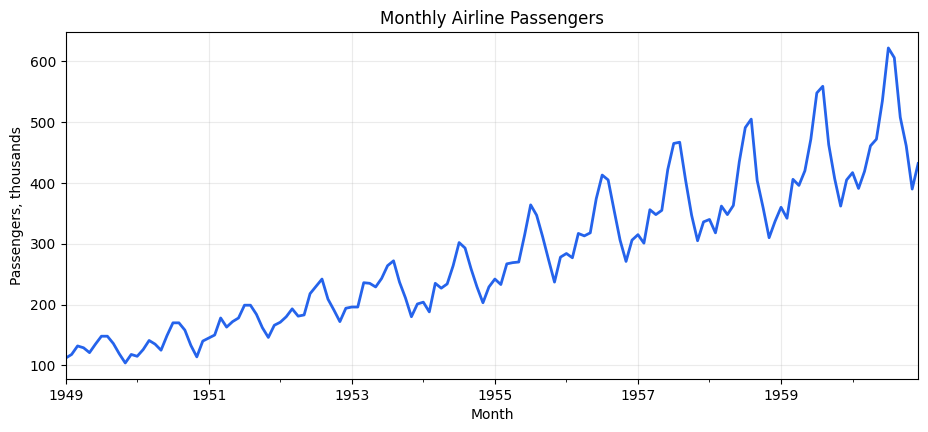

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
df["passengers"].plot(ax=ax, color="#2563EB", linewidth=2)

ax.set_title("Monthly Airline Passengers")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers, thousands")
plt.show()

## 2. What Makes Time Series Different?

In ordinary tabular ML, rows are often treated as independent examples. In time series, row order carries information.

Important differences:

1. Future observations must not be used to create features for the past.
2. Train/test splits should preserve time order.
3. Good baselines are simple time-aware forecasts, such as previous month or same month last year.
4. To use classic ML models, we convert the sequence into a table with lag features.

## 3. Convert the Sequence into Supervised Learning Data

A classic ML regressor expects rows and columns. For a time series, common columns are:

- lag values, such as last month and the same month last year;
- rolling summaries, such as the average of recent months;
- calendar features, such as month of year;
- a trend feature, such as a running time index.

Rolling features are built from shifted data so the current target value does not leak into its own features.

In [4]:
def make_time_series_features(data: pd.DataFrame) -> pd.DataFrame:
    features = data.copy()
    features["time_idx"] = np.arange(len(features))
    features["month_number"] = features.index.month
    features["month_sin"] = np.sin(2 * np.pi * features["month_number"] / 12)
    features["month_cos"] = np.cos(2 * np.pi * features["month_number"] / 12)

    for lag in [1, 2, 3, 12]:
        features[f"lag_{lag}"] = features["passengers"].shift(lag)

    shifted_target = features["passengers"].shift(1)
    features["rolling_mean_3"] = shifted_target.rolling(window=3).mean()
    features["rolling_mean_12"] = shifted_target.rolling(window=12).mean()

    return features.dropna()


supervised = make_time_series_features(df)

feature_columns = [
    "time_idx",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_12",
]

supervised.head()

,passengers,time_idx,month_number,month_sin,month_cos,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_12
month,,,,,,,,,,,
1950-01-01,115,12,1,0.500000,8.660254e-01,118.0,104.0,119.0,112.0,113.666667,126.666667
1950-02-01,126,13,2,0.866025,5.000000e-01,115.0,118.0,104.0,118.0,112.333333,126.916667
1950-03-01,141,14,3,1.000000,6.123234e-17,126.0,115.0,118.0,132.0,119.666667,127.583333
1950-04-01,135,15,4,0.866025,-5.000000e-01,141.0,126.0,115.0,129.0,127.333333,128.333333
1950-05-01,125,16,5,0.500000,-8.660254e-01,135.0,141.0,126.0,121.0,134.000000,128.833333


## 4. Use a Chronological Train/Test Split

For forecasting, the test set should be later than the training set. Here we train on earlier months and test on the final 24 months.

Training range: 1950-01-01 to 1958-12-01
Test range:     1959-01-01 to 1960-12-01
Training rows: 108
Test rows:     24


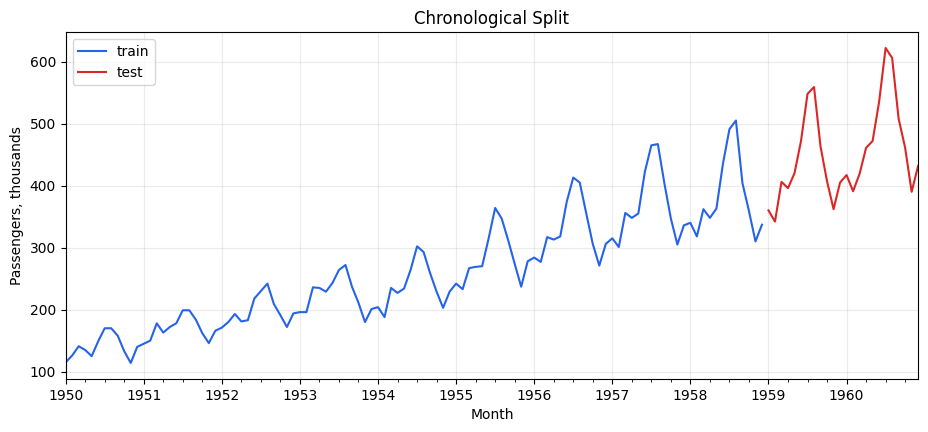

In [5]:
TEST_SIZE = 24

train = supervised.iloc[:-TEST_SIZE].copy()
test = supervised.iloc[-TEST_SIZE:].copy()

X_train = train[feature_columns]
y_train = train["passengers"]
X_test = test[feature_columns]
y_test = test["passengers"]

print(f"Training range: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test range:     {test.index.min().date()} to {test.index.max().date()}")
print(f"Training rows: {len(train)}")
print(f"Test rows:     {len(test)}")

fig, ax = plt.subplots(figsize=(11, 4.5))
train["passengers"].plot(ax=ax, label="train", color="#2563EB")
test["passengers"].plot(ax=ax, label="test", color="#DC2626")
ax.set_title("Chronological Split")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers, thousands")
ax.legend()
plt.show()

## 5. Compare Baselines and Classic ML Models

Always compare ML models to time-aware baselines. If a model cannot beat a simple baseline, the features or model choice need more work.

In [6]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def evaluate(model_name: str, y_true, y_pred) -> dict:
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE %": mape(y_true, y_pred),
    }


ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
forest_model = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)

ridge_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

predictions = pd.DataFrame(index=test.index)
predictions["actual"] = y_test
predictions["naive_previous_month"] = test["lag_1"]
predictions["seasonal_naive_last_year"] = test["lag_12"]
predictions["ridge_regression"] = ridge_model.predict(X_test)
predictions["random_forest"] = forest_model.predict(X_test)

metrics = pd.DataFrame([
    evaluate("Naive: previous month", y_test, predictions["naive_previous_month"]),
    evaluate("Seasonal naive: last year", y_test, predictions["seasonal_naive_last_year"]),
    evaluate("Ridge regression", y_test, predictions["ridge_regression"]),
    evaluate("Random forest", y_test, predictions["random_forest"]),
]).set_index("model").sort_values("RMSE")

metrics

,MAE,RMSE,MAPE %
model,,,
Ridge regression,15.972519,20.049782,3.476738
Seasonal naive: last year,47.583333,49.986665,10.522728
Naive: previous month,44.208333,51.781995,9.729930
Random forest,41.334864,58.996100,8.255591


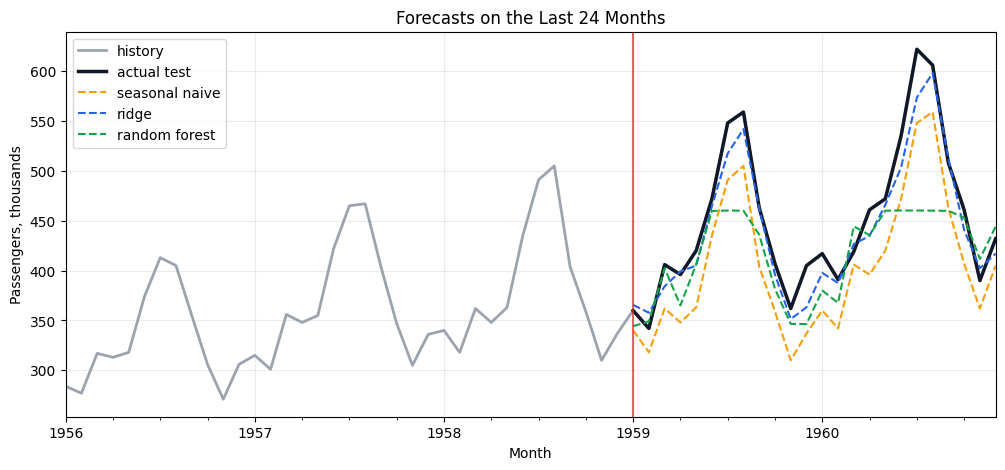

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

df["passengers"].iloc[-60:].plot(ax=ax, color="#9CA3AF", linewidth=2, label="history")
predictions["actual"].plot(ax=ax, color="#111827", linewidth=2.5, label="actual test")
predictions["seasonal_naive_last_year"].plot(ax=ax, color="#F59E0B", linestyle="--", label="seasonal naive")
predictions["ridge_regression"].plot(ax=ax, color="#2563EB", linestyle="--", label="ridge")
predictions["random_forest"].plot(ax=ax, color="#16A34A", linestyle="--", label="random forest")

ax.axvline(test.index.min(), color="#DC2626", linewidth=1.5, alpha=0.7)
ax.set_title("Forecasts on the Last 24 Months")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers, thousands")
ax.legend()
plt.show()

## 6. Cross-Validate Without Shuffling Time

`TimeSeriesSplit` creates validation folds that move forward through time. This is closer to the real forecasting setup than random cross-validation.

In [8]:
X = supervised[feature_columns]
y = supervised["passengers"]

tscv = TimeSeriesSplit(n_splits=5)
cv_mae = -cross_val_score(
    ridge_model,
    X,
    y,
    cv=tscv,
    scoring="neg_mean_absolute_error",
)

split_summary = []
for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), start=1):
    split_summary.append({
        "fold": fold,
        "train_start": X.index[train_idx[0]].date(),
        "train_end": X.index[train_idx[-1]].date(),
        "valid_start": X.index[valid_idx[0]].date(),
        "valid_end": X.index[valid_idx[-1]].date(),
        "validation_MAE": cv_mae[fold - 1],
    })

pd.DataFrame(split_summary)

,fold,train_start,train_end,valid_start,valid_end,validation_MAE
0,1,1950-01-01,1951-10-01,1951-11-01,1953-08-01,19.389473
1,2,1950-01-01,1953-08-01,1953-09-01,1955-06-01,19.938551
2,3,1950-01-01,1955-06-01,1955-07-01,1957-04-01,15.441073
3,4,1950-01-01,1957-04-01,1957-05-01,1959-02-01,19.298240
4,5,1950-01-01,1959-02-01,1959-03-01,1960-12-01,16.832391


## 7. Forecast Future Months Recursively

For one-step-ahead testing, every test row has real previous values. For future forecasting, we do not know next month's actual value yet. A common approach is recursive forecasting: predict one month, append that prediction to the history, then use it to predict the following month.

Recursive forecasts become less reliable farther into the future because model mistakes become inputs for later predictions.

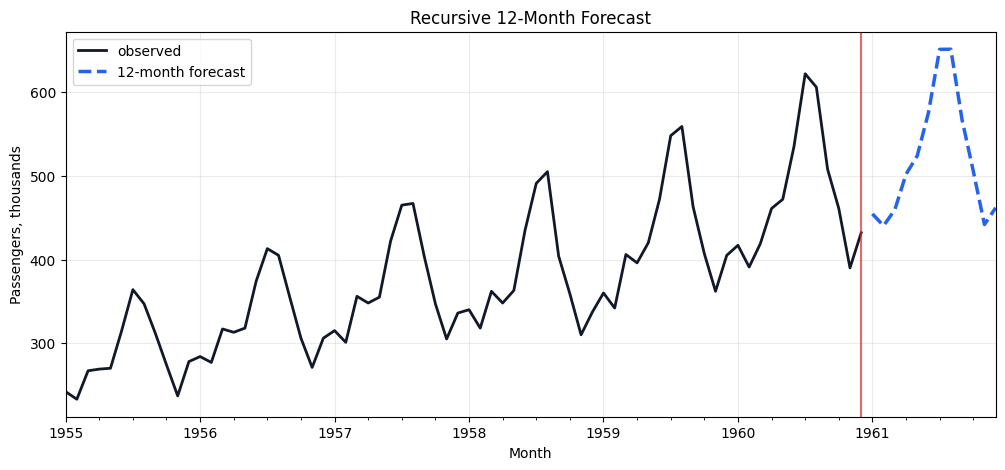

,forecast
month,
1961-01-01,454.5
1961-02-01,440.4
1961-03-01,459.5
1961-04-01,501.9
1961-05-01,523.9
1961-06-01,575.4
1961-07-01,651.2
1961-08-01,651.4
1961-09-01,567.2


In [9]:
def one_step_feature_row(history: pd.Series, next_date: pd.Timestamp) -> pd.DataFrame:
    row = {
        "time_idx": len(history),
        "month_sin": np.sin(2 * np.pi * next_date.month / 12),
        "month_cos": np.cos(2 * np.pi * next_date.month / 12),
        "lag_1": history.iloc[-1],
        "lag_2": history.iloc[-2],
        "lag_3": history.iloc[-3],
        "lag_12": history.iloc[-12],
        "rolling_mean_3": history.iloc[-3:].mean(),
        "rolling_mean_12": history.iloc[-12:].mean(),
    }
    return pd.DataFrame([row], index=[next_date])[feature_columns]


def recursive_forecast(model, history: pd.Series, periods: int) -> pd.Series:
    history = history.copy()
    future_dates = []
    future_values = []

    for _ in range(periods):
        next_date = history.index[-1] + pd.DateOffset(months=1)
        X_next = one_step_feature_row(history, next_date)
        y_next = float(model.predict(X_next)[0])

        future_dates.append(next_date)
        future_values.append(y_next)
        history.loc[next_date] = y_next

    return pd.Series(
        future_values,
        index=pd.DatetimeIndex(future_dates, name=history.index.name),
        name="forecast",
    )


full_ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
full_ridge_model.fit(supervised[feature_columns], supervised["passengers"])

future_forecast = recursive_forecast(full_ridge_model, df["passengers"], periods=12)

fig, ax = plt.subplots(figsize=(12, 5))
df["passengers"].iloc[-72:].plot(ax=ax, color="#111827", linewidth=2, label="observed")
future_forecast.plot(ax=ax, color="#2563EB", linewidth=2.5, linestyle="--", label="12-month forecast")
ax.axvline(df.index.max(), color="#DC2626", linewidth=1.5, alpha=0.7)
ax.set_title("Recursive 12-Month Forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers, thousands")
ax.legend()
plt.show()

future_forecast.round(1).to_frame()

## 8. Main Takeaways

1. Time series forecasting is supervised learning after feature engineering, but row order is essential.
2. Use chronological splits and time-aware cross-validation. Random shuffling gives overly optimistic results.
3. Lag features and shifted rolling windows are the basic bridge from sequences to classic ML.
4. Baselines such as previous month and same month last year are important reference points.
5. Recursive forecasts are useful, but uncertainty grows because each predicted value can affect later predictions.